# Predictive Maintenance — NASA C-MAPSS FD001 (Remaining Useful Life)

**Objective**: Predict the number of remaining cycles before failure RUL (Remaining Useful Life)
for turbofan engines, based on multivariate sensor measurements.

**Dataset**: NASA C-MAPSS, subset **FD001**
- 100 training trajectories (complete run-to-failure)
- 100 test trajectories (truncated before failure)
- 1 single operating condition (sea level), 1 single failure mode (HPC degradation)
- Ground truth provided (`RUL_FD001.txt`) — unlike unsupervised anomaly detection, here we can compute true regression metrics.



## Phase 1 — Setup & Data Loading




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "."  # <-- update if needed

index_names = ['unit', 'cycle']
setting_names = ['os1', 'os2', 'os3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

train = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None, names=col_names)
test = pd.read_csv(f"{DATA_DIR}/test_FD001.txt", sep=r"\s+", header=None, names=col_names)
rul_test = pd.read_csv(f"{DATA_DIR}/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("RUL test shape:", rul_test.shape)
print("Number of units (engines) train:", train['unit'].nunique())
print("Number of units (engines) test :", test['unit'].nunique())
train.head()


Train shape: (20631, 26)
Test shape : (13096, 26)
RUL test shape: (100, 1)
Number of units (engines) train: 100
Number of units (engines) test : 100


,unit,cycle,os1,os2,os3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1.1 — Quick Exploration

How many cycles does each engine live before failure? (In the training set we have the full run-to-failure trajectory.)


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


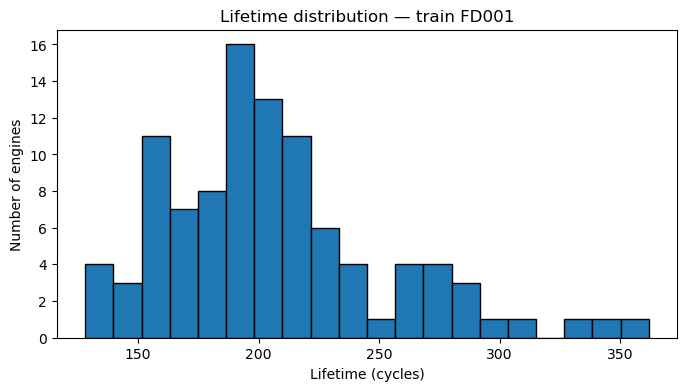

In [2]:
life = train.groupby("unit")["cycle"].max()
print(life.describe())

plt.figure(figsize=(8,4))
plt.hist(life, bins=20, edgecolor="black")
plt.xlabel("Lifetime (cycles)")
plt.ylabel("Number of engines")
plt.title("Lifetime distribution — train FD001")
plt.show()


Check for sensors with near-zero variance — constant sensors carry no information and can distort a scaler.


In [3]:
sensor_stats = train[sensor_names].agg(['mean', 'std'])
print(sensor_stats.T)

low_var_sensors = sensor_stats.loc['std'][sensor_stats.loc['std'] < 1e-4].index.tolist()
print("\nNear-zero variance sensors (to be excluded):", low_var_sensors)


                  mean           std
sensor_1    518.670000  6.537152e-11
sensor_2    642.680934  5.000533e-01
sensor_3   1590.523119  6.131150e+00
sensor_4   1408.933782  9.000605e+00
sensor_5     14.620000  3.394700e-12
sensor_6     21.609803  1.388985e-03
sensor_7    553.367711  8.850923e-01
sensor_8   2388.096652  7.098548e-02
sensor_9   9065.242941  2.208288e+01
sensor_10     1.300000  4.660829e-13
sensor_11    47.541168  2.670874e-01
sensor_12   521.413470  7.375534e-01
sensor_13  2388.096152  7.191892e-02
sensor_14  8143.752722  1.907618e+01
sensor_15     8.442146  3.750504e-02
sensor_16     0.030000  1.556432e-14
sensor_17   393.210654  1.548763e+00
sensor_18  2388.000000  0.000000e+00
sensor_19   100.000000  0.000000e+00
sensor_20    38.816271  1.807464e-01
sensor_21    23.289705  1.082509e-01

Near-zero variance sensors (to be excluded): ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


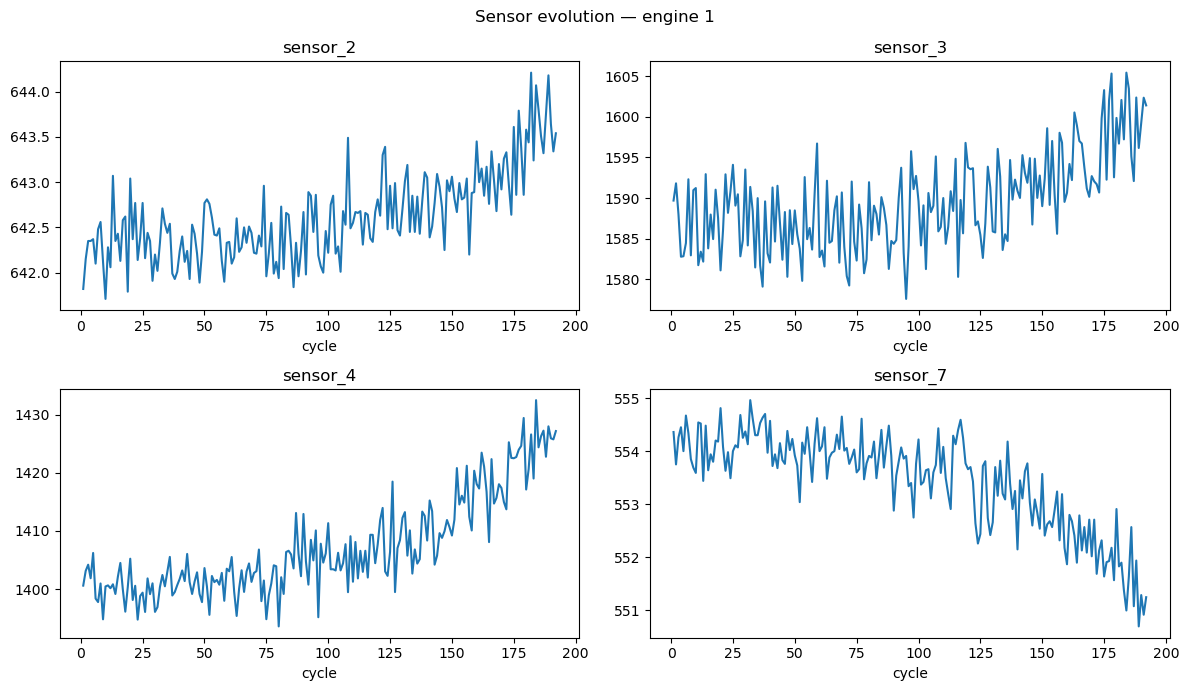

In [4]:
# Visualise a few sensors for one engine (degradation visible near end-of-life)
unit_example = 1
df_u = train[train["unit"] == unit_example]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, s in zip(axes.flat, ["sensor_2", "sensor_3", "sensor_4", "sensor_7"]):
    if s in df_u.columns:
        ax.plot(df_u["cycle"], df_u[s])
        ax.set_title(s)
        ax.set_xlabel("cycle")
plt.suptitle(f"Sensor evolution — engine {unit_example}")
plt.tight_layout()
plt.show()


## Phase 2 — RUL Target Construction & Feature Engineering

**RUL (train)** = `max_cycle_of_engine − current_cycle` (at end of life, RUL = 0).

**Clipping**: This is standard practice on C-MAPSS. At the start of life, the "true" RUL is
enormous and unrelated to the actual degradation state (no sensor can distinguish RUL=250 from
RUL=280
the engine is simply healthy). We therefore cap the RUL at a reasonable value
(125 is the most widely used in the FD001 literature) to prevent the model from trying to learn
the impossible on the "healthy" portion of the engine's life.


In [5]:
RUL_CLIP = 125

max_cycle = train.groupby("unit")["cycle"].transform("max")
train["RUL"] = max_cycle - train["cycle"]
train["RUL_clipped"] = train["RUL"].clip(upper=RUL_CLIP)

train[["unit", "cycle", "RUL", "RUL_clipped"]].head(10)


,unit,cycle,RUL,RUL_clipped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


In [6]:
feature_sensors = [s for s in sensor_names if s not in low_var_sensors]
print(f"Retained sensors ({len(feature_sensors)}):", feature_sensors)

def add_rolling(df, cols, window=5):
    df = df.copy()
    for c in cols:
        df[f"{c}_roll_mean"] = df.groupby("unit")[c].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f"{c}_roll_std"] = df.groupby("unit")[c].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

train_fe = add_rolling(train, feature_sensors)
test_fe = add_rolling(test, feature_sensors)

feature_cols = (feature_sensors + setting_names
                + [f"{c}_roll_mean" for c in feature_sensors]
                + [f"{c}_roll_std" for c in feature_sensors])
print(f"\nTotal number of features: {len(feature_cols)}")


Retained sensors (15): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Total number of features: 48


## Phase 3: Baseline: Tabular Model (Random Forest)

**Standard C-MAPSS test protocol**: For each test engine we only have a truncated trajectory 
the true RUL provided corresponds to the **last observed cycle**. We therefore train on all
training rows (each cycle has its own RUL), but evaluate only on the last cycle of each test
unit (this is the PHM08 challenge convention).


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train_fe[feature_cols])
y_train = train_fe["RUL_clipped"].values

test_last = test_fe.groupby("unit").last().reset_index()
X_test = scaler.transform(test_last[feature_cols])
y_test = rul_test["RUL"].values

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (20631, 48)  X_test: (100, 48)


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.2f}   MAE: {mae_rf:.2f}")


Random Forest — RMSE: 18.85   MAE: 13.63


### (Optional) XGBoost often slightly better than RF on this type of tabular data


In [9]:
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=42)
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
    mae_xgb = mean_absolute_error(y_test, pred_xgb)
    print(f"XGBoost — RMSE: {rmse_xgb:.2f}   MAE: {mae_xgb:.2f}")
except ImportError:
    print("xgboost not installed — run `pip install xgboost` to enable it")


XGBoost — RMSE: 19.03   MAE: 14.23


## Phase 4: PHM08 Score (Official Challenge Metric)

RMSE treats over-estimation and under-estimation symmetrically. In real predictive maintenance,
**under-estimating RUL** (saying "it will break soon" when there is still time left) triggers an
unnecessary maintenance intervention, annoying but not dangerous. **Over-estimating RUL**
(saying "it will last much longer" when it is about to fail) can lead to an in-service breakdown,
far more costly and dangerous. The PHM08 score therefore penalises over-estimation more heavily
(exponential asymmetry).


In [10]:
def phm_score(y_true, y_pred):
    """Official PHM08 score. Lower is better. Asymmetric:
    penalises RUL over-estimation (y_pred > y_true) more heavily."""
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(s)

print(f"Random Forest — PHM score: {phm_score(y_test, pred_rf):.1f}")
try:
    print(f"XGBoost       — PHM score: {phm_score(y_test, pred_xgb):.1f}")
except NameError:
    pass


Random Forest — PHM score: 1038.5
XGBoost       — PHM score: 920.7


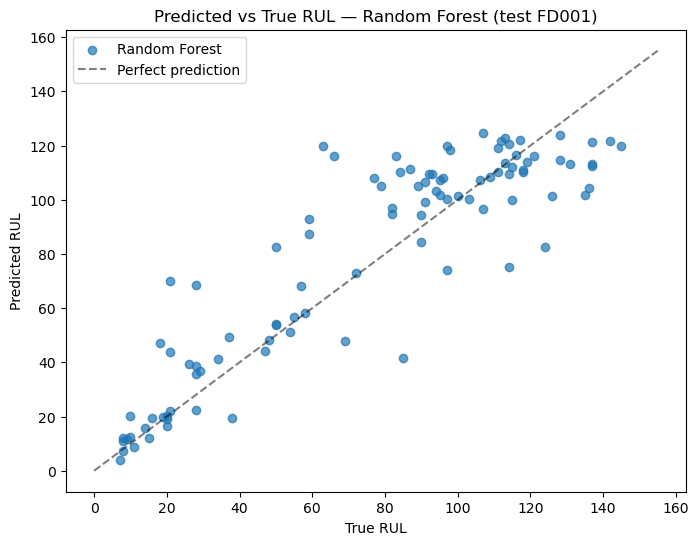

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_rf, alpha=0.7, label="Random Forest")
lims = [0, max(y_test.max(), pred_rf.max()) + 10]
plt.plot(lims, lims, 'k--', alpha=0.5, label="Perfect prediction")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL — Random Forest (test FD001)")
plt.legend()
plt.show()


## Phase 5: Sequential Model (LSTM)

Unlike the Random Forest (which sees only one cycle at a time), the LSTM receives a
**sliding window** of `SEQ_LEN` consecutive cycles  it can therefore learn the *dynamics*
of degradation, not just an instantaneous state.


In [12]:
SEQ_LEN = 30  # number of historical cycles per sequence

def gen_sequences(df, feature_cols, seq_len, target_col="RUL_clipped"):
    seqs, targets = [], []
    for uid, g in df.groupby("unit"):
        data = g[feature_cols].values
        rul = g[target_col].values
        if len(data) < seq_len:
            continue  # engine too short to form a full sequence
        for i in range(len(data) - seq_len + 1):
            seqs.append(data[i:i + seq_len])
            targets.append(rul[i + seq_len - 1])
    return np.array(seqs), np.array(targets)

train_fe_scaled = train_fe.copy()
train_fe_scaled[feature_cols] = scaler.transform(train_fe[feature_cols])

X_seq, y_seq = gen_sequences(train_fe_scaled, feature_cols, SEQ_LEN)
print("X_seq:", X_seq.shape, " y_seq:", y_seq.shape)

from sklearn.model_selection import train_test_split
X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)


X_seq: (17731, 30, 48)  y_seq: (17731,)


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()


C:\Users\nfsbu\anaconda\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,889 (163.63 KB)

 Trainable params: 41,889 (163.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 5296.0210 - val_loss: 2747.0005
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 1468.4601 - val_loss: 579.7310
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 401.0543 - val_loss: 211.5138
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 214.9004 - val_loss: 127.7755
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 158.9443 - val_loss: 77.5659
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 130.7890 - val_loss: 59.4711
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 114.2163 - val_loss: 47.6745
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 104.1365 - val_loss: 37.1024
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 93.7249 - val_loss: 33.2341
Epoch 10/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 91.6080 - val_loss: 27.9433
Epoch 11/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 87.6266 - val_loss: 

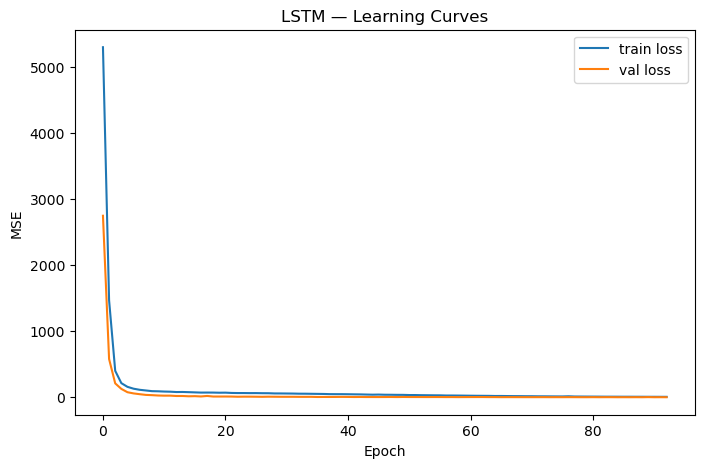

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend()
plt.title("LSTM — Learning Curves")
plt.show()


### LSTM Evaluation on Test Set

Same protocol as for RF: for each test engine we take its **last window** of `SEQ_LEN` cycles
(engines too short are skipped flag it if this happens often, as it would suggest reducing `SEQ_LEN`).


In [16]:
def last_sequence_per_unit(df, feature_cols, seq_len):
    seqs, units = [], []
    for uid, g in df.groupby("unit"):
        data = g[feature_cols].values
        if len(data) < seq_len:
            units.append(uid)  # too short -> excluded, worth monitoring
            continue
        seqs.append(data[-seq_len:])
    return np.array(seqs), units

test_fe_scaled = test_fe.copy()
test_fe_scaled[feature_cols] = scaler.transform(test_fe[feature_cols])

X_test_seq, excluded_units = last_sequence_per_unit(test_fe_scaled, feature_cols, SEQ_LEN)
print(f"Valid test sequences: {X_test_seq.shape[0]} / {test_fe['unit'].nunique()}")
if excluded_units:
    print(f"⚠️ Excluded units (too short for SEQ_LEN={SEQ_LEN}): {excluded_units}")

pred_lstm = lstm_model.predict(X_test_seq).flatten()

# Align y_test with the units actually kept (some may be excluded if too short for SEQ_LEN)
all_units = sorted(test_fe['unit'].unique())
kept_units = [u for u in all_units if u not in excluded_units]
y_test_lstm = rul_test["RUL"].values[[all_units.index(u) for u in kept_units]]

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, pred_lstm))
mae_lstm = mean_absolute_error(y_test_lstm, pred_lstm)
print(f"LSTM — RMSE: {rmse_lstm:.2f}   MAE: {mae_lstm:.2f}")
print(f"LSTM — PHM score: {phm_score(y_test_lstm, pred_lstm):.1f}")


Valid test sequences: 100 / 100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step
LSTM — RMSE: 18.07   MAE: 13.86
LSTM — PHM score: 779.1


## Phase 6: Model Comparison & Conclusion


In [17]:
results = pd.DataFrame({
    "Model": ["Random Forest", "LSTM"],
    "RMSE": [rmse_rf, rmse_lstm],
    "PHM score": [phm_score(y_test, pred_rf), phm_score(y_test_lstm, pred_lstm)]
})
try:
    results.loc[len(results)] = ["XGBoost", rmse_xgb, phm_score(y_test, pred_xgb)]
except NameError:
    pass

print(results.sort_values("RMSE"))


           Model       RMSE    PHM score
1           LSTM  18.069211   779.140082
0  Random Forest  18.848145  1038.489536
2        XGBoost  19.027508   920.687666


### 6.1 — Error Distribution (predicted − true RUL)




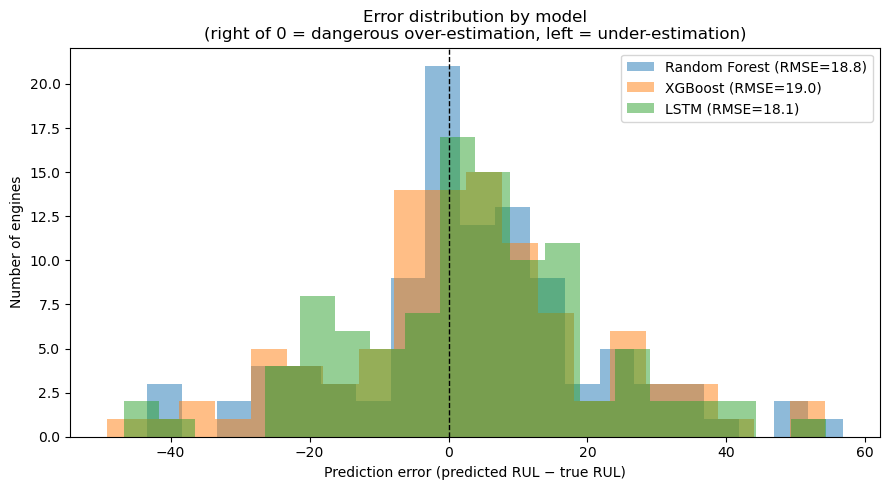

Random Forest   — over-estimation: 62.0%   under-estimation: 38.0%   mean error: +3.39 cycles
LSTM            — over-estimation: 64.0%   under-estimation: 36.0%   mean error: +3.33 cycles
XGBoost         — over-estimation: 56.0%   under-estimation: 44.0%   mean error: +2.65 cycles


In [19]:
err_rf = pred_rf - y_test
err_lstm = pred_lstm - y_test_lstm

plt.figure(figsize=(9, 5))
plt.hist(err_rf, bins=20, alpha=0.5, label=f"Random Forest (RMSE={rmse_rf:.1f})", color="tab:blue")
try:
    err_xgb = pred_xgb - y_test
    plt.hist(err_xgb, bins=20, alpha=0.5, label=f"XGBoost (RMSE={rmse_xgb:.1f})", color="tab:orange")
except NameError:
    pass
plt.hist(err_lstm, bins=20, alpha=0.5, label=f"LSTM (RMSE={rmse_lstm:.1f})", color="tab:green")

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction error (predicted RUL − true RUL)")
plt.ylabel("Number of engines")
plt.title("Error distribution by model\n(right of 0 = dangerous over-estimation, left = under-estimation)")
plt.legend()
plt.tight_layout()
plt.savefig("phase6_error_distribution.png", dpi=100)
plt.show()

# Summary: share of over-estimation vs under-estimation errors
for name, err in [("Random Forest", err_rf), ("LSTM", err_lstm)] + (
    [("XGBoost", err_xgb)] if "err_xgb" in dir() else []):
    over = (err > 0).mean() * 100
    under = (err <= 0).mean() * 100
    print(f"{name:15s} — over-estimation: {over:.1f}%   under-estimation: {under:.1f}%   "
          f"mean error: {err.mean():+.2f} cycles")
